<div style="background-color: lightblue; text-align: center; padding: 8px; border-radius: 10px;">
    <span style="font-weight: bold; font-size: 24px; color: lightblack;">
        Сборный проект 5
    </span>
</div>

<span style="background-color: #008000; text-align: center; padding: 10px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 24px; color: white;">
        Преамбула проекта
    </span>
</span>

**Цель проекта** - на основании датасетов, содержащих экспертные и краудсорсинговые оценки соответствия текста и изображения, разработать демонстрационную модель, позволяющую искать изображения по запросу.
  
**Задачи проекта** - на основе исторических данных о заказах такси в аэропортах разработать модель машинного обучения, способную спрогнозировать количество заказов такси на следующий час.

<span style="background-color: #008000; text-align: center; padding: 10px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 24px; color: white;">
        Структура проекта
    </span>
</span>

<div style="text-align: left;">
    <span style="font-weight: bold; font-size: 18px; color: black; font-family: Arial, sans-serif;">
        Проект состоит из следующийх этапов:
    </span>
</div>

**Этап 1:** Загрузка и подготовка данных.  
**Этап 2:** Предобработка данных.  
**Этап 3:** EDA.  
**Этап 4:** Проверка данных. Фильтрация контента.  
**Этап 5:** Подготовка данных.  
**Этап 6:** Векторизация изображений.  
**Этап 7:** Векторизация текста.  
**Этап 8:** Объединение векторов.  
**Этап 9:** Обучение модели.  
**Этап 10:** Тестирование лучшей модели.  
**Этап 11:** Выводы и рекомендации.

<span style="background-color: #6495ED; text-align: center; padding: 8px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 20px; color: white;">
        Этап 1. Загрузка и подготовка данных
    </span>
</span>

<span style="background-color: #8FBC8F; text-align: center; padding: 6px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 18px; color: white;">
        Подготовка рабочего пространства.
        Необходимые импорты
    </span>
</span>

**Импортируем необходимые библиотеки:**

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import random
import os
import re
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

from collections import Counter
from scipy.stats import spearmanr, pearsonr

from PIL import Image
from itertools import product

from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import (resnet50,
                                ResNet50_Weights
)

from transformers import (
    AutoTokenizer,
    AutoModel
)

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from lightgbm import LGBMRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

**Определим пути доступа к файлам:**

In [3]:
PROJECT_DIR = Path('/content/drive/MyDrive/ML_Projects/Project_5_Files')
TRAIN_IMAGES_PATH = PROJECT_DIR / 'train_images'
TEST_IMAGES_PATH = PROJECT_DIR / 'test_images'

print(PROJECT_DIR)
print(TRAIN_IMAGES_PATH)
print(TEST_IMAGES_PATH)

/content/drive/MyDrive/ML_Projects/Project_5_Files
/content/drive/MyDrive/ML_Projects/Project_5_Files/train_images
/content/drive/MyDrive/ML_Projects/Project_5_Files/test_images


**Определим константы:**

In [4]:
RANDOM_STATE = 2026
TEST_SIZE = 0.25

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

**Определим устройство для обучения модели:**

In [5]:
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

DEVICE = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print(f'Используется: {DEVICE}')

Используется: cuda


**Кастомизируем визуализацию:**

In [6]:
plt.rcParams.update({
    'font.family':        'Liberation Sans',
    'font.size':          10,
    'axes.titlesize':     14,
    'axes.titleweight':   'bold',
    'axes.labelsize':     12,
    'xtick.labelsize':    13,
    'ytick.labelsize':    13,
    'text.color':         '#2C3E50',
    'axes.labelcolor':    '#2C3E50',
    'xtick.color':        '#555555',
    'ytick.color':        '#555555',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.edgecolor':     '#CCCCCC',
    'axes.grid':          True,
    'grid.color':         '#E8E8E8',
    'grid.linewidth':     0.6,
    'axes.axisbelow':     True,
    'figure.facecolor':   'white',
    'savefig.facecolor':  'white',
    'savefig.dpi':        150,
    'figure.dpi':         100,
})

BLUE   = '#2E86C1'
RED    = '#E74C3C'
GREEN  = '#27AE60'
ORANGE = '#E67E22'
TEAL   = '#1ABC9C'
DARK   = '#2C3E50'
AMBER  = '#F39C12'
PURPLE = '#9B59B6'

CAT_COLORS = [BLUE, RED, GREEN, ORANGE, PURPLE, TEAL, AMBER, PURPLE]

**Загрузим датасеты:**

In [7]:
# Тренировочный датасет:

train_df = pd.read_csv(
    PROJECT_DIR / 'train_dataset.csv',
    encoding='utf-8'
)

In [8]:
# Датасет с оценками краудфандинга:

crowd_annotations_df = pd.read_csv(
    PROJECT_DIR / 'CrowdAnnotations.tsv',
    encoding='utf-8',
    sep='\t',
    header=None,
    names=['image', 'query_id', 'fraction', 'count_yes', 'count_no']
)

In [9]:
# Датасет с оценками экспертов:

expert_annotations_df = pd.read_csv(
    PROJECT_DIR / 'ExpertAnnotations.tsv',
    encoding='utf-8',
    sep='\t',
    header=None,
    names=['image', 'query_id', 'expert_1', 'expert_2', 'expert_3']
)

In [10]:
# Датасет для тестовых запросов:

test_queries_df = pd.read_csv(
    PROJECT_DIR / 'test_queries.csv',
    encoding='utf-8',
    sep='|'
)

In [11]:
# Датасет с тестовыми изображениями:

test_images_df = pd.read_csv(
    PROJECT_DIR / 'test_images.csv',
    encoding='utf-8'
)

**Проверим корректность загрузки датасетов:**

In [12]:
display(train_df.head(2))
train_df.shape

,image,query_id,query_text
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...
1,1262583859_653f1469a9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...


(5822, 3)

In [13]:
display(crowd_annotations_df.head(2))
crowd_annotations_df.shape

,image,query_id,fraction,count_yes,count_no
0,1056338697_4f7d7ce270.jpg,1056338697_4f7d7ce270.jpg#2,1.0,3,0
1,1056338697_4f7d7ce270.jpg,114051287_dd85625a04.jpg#2,0.0,0,3


(47830, 5)

In [14]:
display(expert_annotations_df.head(2))
expert_annotations_df.shape

,image,query_id,expert_1,expert_2,expert_3
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,1,1,1
1,1056338697_4f7d7ce270.jpg,2718495608_d8533e3ac5.jpg#2,1,1,2


(5822, 5)

In [15]:
display(test_queries_df.head(2))
test_queries_df.shape

,Unnamed: 0,query_id,query_text,image
0,0,1177994172_10d143cb8d.jpg#0,"Two blonde boys , one in a camouflage shirt an...",1177994172_10d143cb8d.jpg
1,1,1177994172_10d143cb8d.jpg#1,Two boys are squirting water guns at each other .,1177994172_10d143cb8d.jpg


(500, 4)

In [16]:
display(test_images_df.head(2))
test_images_df.shape

,image
0,3356748019_2251399314.jpg
1,2887171449_f54a2b9f39.jpg


(100, 1)

Данные загружены корректно. Можно приступать к предобработке данных

<span style="background-color: #6495ED; text-align: center; padding: 8px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 20px; color: white;">
        Этап 2. Предобработка данных
    </span>
</span>

В датасете с тестовыми запросами 'test_queries_ds' есть неинформативный столбец 'Unnamed: 0', дублирующий основной индекс. Удалим его:  

In [17]:
test_queries_df.drop(columns='Unnamed: 0', inplace=True)
display(test_queries_df.head(2))

,query_id,query_text,image
0,1177994172_10d143cb8d.jpg#0,"Two blonde boys , one in a camouflage shirt an...",1177994172_10d143cb8d.jpg
1,1177994172_10d143cb8d.jpg#1,Two boys are squirting water guns at each other .,1177994172_10d143cb8d.jpg


Удаление произошло успешно.

**Проведем проверки на пропуски, дубликаты, на соответствие типов данных**

In [18]:
datasets = {
    'train_df': train_df,
    'crowd_annotations_df': crowd_annotations_df,
    'expert_annotations_df': expert_annotations_df,
    'test_queries_df': test_queries_df,
    'test_images_df': test_images_df
}

**Тип данных:**

In [19]:
for name, df in datasets.items():
    print(f'\n{name}')
    print(df.dtypes)


train_df
image         object
query_id      object
query_text    object
dtype: object

crowd_annotations_df
image         object
query_id      object
fraction     float64
count_yes      int64
count_no       int64
dtype: object

expert_annotations_df
image       object
query_id    object
expert_1     int64
expert_2     int64
expert_3     int64
dtype: object

test_queries_df
query_id      object
query_text    object
image         object
dtype: object

test_images_df
image    object
dtype: object


**Пропущенные значения:**

In [20]:
for name, df in datasets.items():
    print(f'\n{name}')
    display(df.isna().sum().to_frame('missing'))


train_df


,missing
image,0
query_id,0
query_text,0



crowd_annotations_df


,missing
image,0
query_id,0
fraction,0
count_yes,0
count_no,0



expert_annotations_df


,missing
image,0
query_id,0
expert_1,0
expert_2,0
expert_3,0



test_queries_df


,missing
query_id,0
query_text,0
image,0



test_images_df


,missing
image,0


**Дубликаты:**

In [21]:
for name, df in datasets.items():
    print(f'{name:}: {df.duplicated().sum()}')

train_df: 0
crowd_annotations_df: 0
expert_annotations_df: 0
test_queries_df: 0
test_images_df: 0


In [22]:
print('train_df')
print(f'Уникальных изображений: {train_df["image"].nunique()}')
print(f'Уникальных query_id: {train_df["query_id"].nunique()}')
print(f'Уникальных текстов: {train_df["query_text"].nunique()}')

print('\ncrowd_annotations_df')
print(f'Уникальных изображений: {crowd_annotations_df["image"].nunique()}')
print(f'Уникальных query_id: {crowd_annotations_df["query_id"].nunique()}')

print('\nexpert_annotations_df')
print(f'Уникальных изображений: {expert_annotations_df["image"].nunique()}')
print(f'Уникальных query_id: {expert_annotations_df["query_id"].nunique()}')

print('\ntest_queries_df')
print(f'Уникальных изображений: {test_queries_df["image"].nunique()}')
print(f'Уникальных query_id: {test_queries_df["query_id"].nunique()}')
print(f'Уникальных текстов: {test_queries_df["query_text"].nunique()}')

train_df
Уникальных изображений: 1000
Уникальных query_id: 977
Уникальных текстов: 977

crowd_annotations_df
Уникальных изображений: 1000
Уникальных query_id: 1000

expert_annotations_df
Уникальных изображений: 1000
Уникальных query_id: 977

test_queries_df
Уникальных изображений: 100
Уникальных query_id: 500
Уникальных текстов: 500


**Промежуточный вывод:**  
Пропущенные значения и полные дубликаты в рассмотренных таблицах отсутствуют. Типы данных соответствуют.  
  
В обучающем датасете содержится 5 822 пары "картинка — текстовое описание", включающие 1 000 уникальных изображений и 977 уникальных описаний.  
Экспертная разметка содержит оценки для такого же количества пар.  
Краудсорсинговая разметка значительно больше — 47 830 пар для 1 000 изображений и 1 000 описаний.  
  
Тестовая выборка содержит 500 уникальных текстовых запросов для 100 изображений.  
  
Повторение query_id в обучающих данных не является дублированием: одно текстовое описание может сопоставляться с несколькими изображениями, поскольку задача состоит в оценке соответствия конкретной пары «изображение — текст».

<span style="background-color: #6495ED; text-align: center; padding: 8px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 20px; color: white;">
        Этап 3. EDA
    </span>
</span>

<span style="background-color: #879e72; text-align: center; padding: 6px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 18px; color: white;">
        Оценки экспертов
    </span>
</span>

Проведем анализ оценок экспертов

In [23]:
expert_annotations_df.describe()

,expert_1,expert_2,expert_3
count,5822.000000,5822.000000,5822.000000
mean,1.436620,1.624356,1.881999
std,0.787084,0.856222,0.904087
min,1.000000,1.000000,1.000000
25%,1.000000,1.000000,1.000000
50%,1.000000,1.000000,2.000000
75%,2.000000,2.000000,2.000000
max,4.000000,4.000000,4.000000


In [24]:
expert_columns = ['expert_1', 'expert_2', 'expert_3']

for col in expert_columns:
    print(f'{col}: {sorted(expert_annotations_df[col].unique())}')

expert_1: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
expert_2: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
expert_3: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


Все оценки экспертов находятся в предусмотренном условиями диапазоне от 1 до 4.

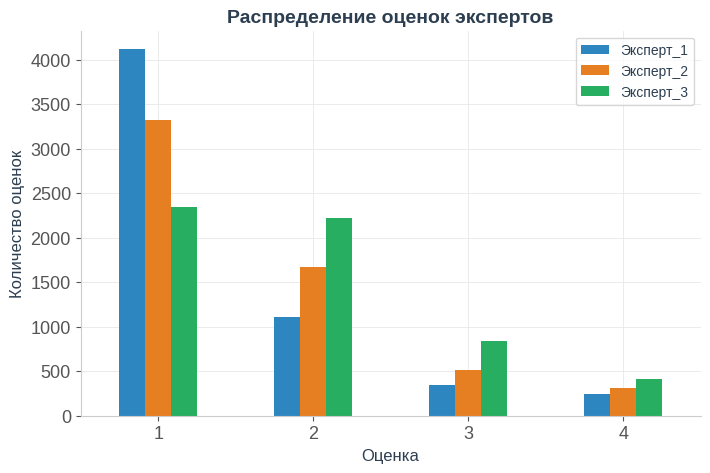

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))

expert_annotations_df[expert_columns].apply(
    pd.Series.value_counts
).sort_index().plot(
    kind='bar',
    ax=ax,
    color=[BLUE, ORANGE, GREEN]
)

ax.set_title('Распределение оценок экспертов')
ax.set_xlabel('Оценка')
ax.set_ylabel('Количество оценок')
ax.legend(['Эксперт_1', 'Эксперт_2', 'Эксперт_3'])
ax.tick_params(axis='x', rotation=0)

plt.show()

**Проверим, насколько оценки экспертов согласуются/разнятся друг с другом:**

In [26]:
def agreement_type(row):
    scores = row[expert_columns].values
    n_unique = len(set(scores))

    if n_unique == 1:
        return '3 из 3'
    elif n_unique == 2:
        return '2 из 3'
    else:
        return 'Разные оценки'


expert_annotations_df['agreement'] = expert_annotations_df.apply(
    agreement_type,
    axis=1
)

agreement_stats = (
    expert_annotations_df['agreement']
    .value_counts()
    .to_frame('count')
)

agreement_stats['share_%'] = (
    agreement_stats['count']
    / len(expert_annotations_df)
    * 100
).round(2)

agreement_stats

,count,share_%
agreement,,
3 из 3,3391,58.24
2 из 3,2305,39.59
Разные оценки,126,2.16


In [27]:
agreement_stats = (
    expert_annotations_df['agreement']
    .value_counts()
    .to_frame('count')
)

agreement_stats['share_%'] = (
    agreement_stats['count']
    / len(expert_annotations_df)
    * 100
).round(2)

agreement_stats

,count,share_%
agreement,,
3 из 3,3391,58.24
2 из 3,2305,39.59
Разные оценки,126,2.16


Все оценки экспертов находятся в диапазоне от 1 до 4.  
В распределении оценок преобладают низкие значения, особенно оценка 1, что свидетельствует о значительной доле нерелевантных пар "фотография — описание".  
Эксперты показывают высокий уровень согласованности:
* в 58.25% случаев оценки всех трёх экспертов полностью совпадают;  
* в 39.59% случаев совпадают оценки двух из трёх экспертов;  
* для 2.16% пар все три оценки различаются.

**Агрегируем оценки по баллам и их количеству:**

In [28]:
def majority_vote(row):
    scores = row[expert_columns]
    counts = scores.value_counts()

    if counts.iloc[0] >= 2:
        return counts.index[0]

    return np.nan


expert_annotations_df['expert_score'] = expert_annotations_df.apply(
    majority_vote,
    axis=1
)

expert_annotations_df['expert_score'].value_counts(
    dropna=False
).sort_index()

,count
expert_score,
1.0,3327
2.0,1566
3.0,492
4.0,311
NaN,126


Оценки сагрегированы.  
126 оценок не попавшие в одну из четырех категорий, временно сагрегированы в отдельный признак 'Nan'.  

<span style="background-color: #879e72; text-align: center; padding: 6px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 18px; color: white;">
        Оценки краудсорсеров
    </span>
</span>

Проведем анализ оценок краудсорсеров

In [29]:
crowd_annotations_df[
    ['fraction', 'count_yes', 'count_no']
].describe()

,fraction,count_yes,count_no
count,47830.000000,47830.000000,47830.000000
mean,0.068786,0.208488,2.820155
std,0.207532,0.628898,0.656676
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,3.000000
50%,0.000000,0.000000,3.000000
75%,0.000000,0.000000,3.000000
max,1.000000,5.000000,6.000000


Краудсорсинговая разметка имеет выраженный дисбаланс в сторону несоответствующих пар.  
Среднее значение доли положительных ответов составляет около 0.069.  
Как минимум 75% пар не получили ни одного подтверждения соответствия со стороны исполнителей.  
Медианное количество отрицательных голосов равно 3, что соответствует наиболее распространённому числу оценивших одну пару.  

**Проверим, сколько человек оценивало каждую связку "изображение—текст":**

In [30]:
crowd_annotations_df['total_votes'] = (
    crowd_annotations_df['count_yes']
    + crowd_annotations_df['count_no']
)

crowd_annotations_df['total_votes'].value_counts().sort_index()

,count
total_votes,
3,46780
4,780
5,220
6,50


Большинство пар "изображение—описание" (46 780 из 47 830) были оценены тремя исполнителями.  
Для небольшой части пар количество оценок составило от 4 до 6.  
Таким образом, краудсорсинговая разметка в основном получена при одинаковом количестве голосов, а различия в числе исполнителей затрагивают лишь небольшую часть данных.

**Проверим корректность расчета *'fraction'***:

In [31]:
crowd_annotations_df['fraction'].value_counts().sort_index()

calculated_fraction = (
    crowd_annotations_df['count_yes']
    / crowd_annotations_df['total_votes']
)

np.allclose(
    crowd_annotations_df['fraction'],
    calculated_fraction
)

True

Значения *'fraction'* корректно рассчитаны как отношение количества положительных голосов к общему числу голосов.  
Данный показатель можно использовать в дальнейшем анализе как агрегированную оценку соответствия изображения описанию.  


**Визуализируем распределение *'fraction'***

Для нормального объективного отображения используем логарифмическую шкалу

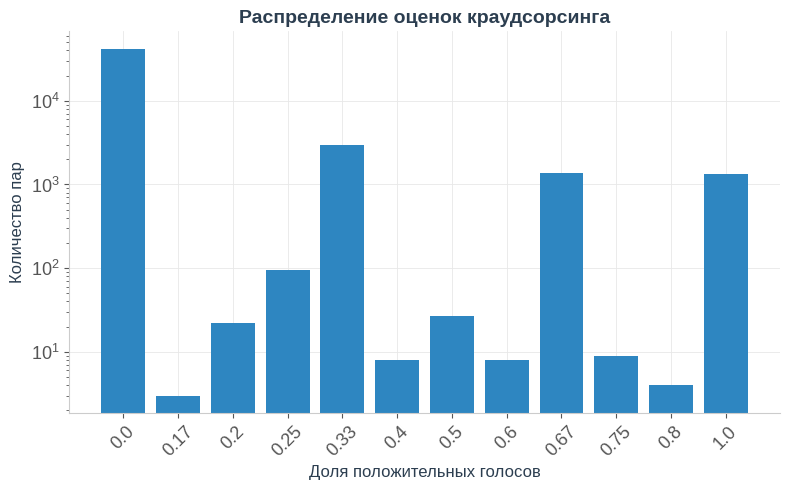

In [32]:
fraction_counts = (
    crowd_annotations_df['fraction']
    .round(2)
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    fraction_counts.index.astype(str),
    fraction_counts.values,
    color=BLUE
)

ax.set_yscale('log')

ax.set_title('Распределение оценок краудсорсинга')
ax.set_xlabel('Доля положительных голосов')
ax.set_ylabel('Количество пар')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Диаграмма показывает дисбаланс в сторону нулевой отметки - ни один из краудсорсеров не подтвердил соответствие связки "изображения-текст".  
Выраженные пики около 0.33, 0.67 и 1.0; остальные значения возникают у сравнительно редких связок, которые оценивали 4–6 человек.  

<span style="background-color: #879e72; text-align: center; padding: 6px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 18px; color: white;">
        Сопоставление экспертной и краудсорсинговой разметок в связке 'image' - 'query_id'
    </span>
</span>

Проверим на дубликаты:

In [33]:
print(
    'Повторяющиуся связки у экспертов:',
    expert_annotations_df.duplicated(['image', 'query_id']).sum()
)

print(
    'Повторяющиеся связки у краудсорсеров:',
    crowd_annotations_df.duplicated(['image', 'query_id']).sum()
)

Повторяющиуся связки у экспертов: 0
Повторяющиеся связки у краудсорсеров: 0


Объединим данные:

In [34]:
annotation_compare_df = (
    expert_annotations_df[
        ['image', 'query_id', 'expert_score']
    ]
    .merge(
        crowd_annotations_df[
            ['image', 'query_id', 'fraction']
        ],
        on=['image', 'query_id'],
        how='inner'
    )
)

annotation_compare_df.head()

,image,query_id,expert_score,fraction
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,1.0,0.000000
1,1056338697_4f7d7ce270.jpg,2718495608_d8533e3ac5.jpg#2,1.0,0.000000
2,1056338697_4f7d7ce270.jpg,434792818_56375e203f.jpg#2,1.0,0.000000
3,1082379191_ec1e53f996.jpg,1536774449_e16b1b6382.jpg#2,NaN,0.000000
4,1084040636_97d9633581.jpg,256085101_2c2617c5d0.jpg#2,3.0,0.333333


**Проверим значения:**

In [35]:
print('Размер объединённой таблицы:', annotation_compare_df.shape)

print(
    'Строк без итоговой экспертной оценки:',
    annotation_compare_df['expert_score'].isna().sum()
)

Размер объединённой таблицы: (2329, 4)
Строк без итоговой экспертной оценки: 71


In [36]:
print(
    'Уникальных пар у экспертов:',
    expert_annotations_df[
        ['image', 'query_id']
    ].drop_duplicates().shape[0]
)

print(
    'Уникальных пар у крауда:',
    crowd_annotations_df[
        ['image', 'query_id']
    ].drop_duplicates().shape[0]
)

print(
    'Повторов ключа у экспертов:',
    expert_annotations_df.duplicated(
        ['image', 'query_id']
    ).sum()
)

print(
    'Повторов ключа у крауда:',
    crowd_annotations_df.duplicated(
        ['image', 'query_id']
    ).sum()
)

Уникальных пар у экспертов: 5822
Уникальных пар у крауда: 47830
Повторов ключа у экспертов: 0
Повторов ключа у крауда: 0


Связка "image + query_id" является уникальной в обеих таблицах, повторяющиеся пары отсутствуют.  
Экспертная разметка содержит 5 822 уникальные пары, а краудсорсинговая — 47 830.  
При объединении таблиц обнаружено 2 329 общих пар. Следовательно, различие в размерах после объединения обусловлено не дубликатами, а тем, что два источника разметки охватывают разные наборы пар "изображение—описание".

Удалим 71 строку, где не удалось определить результат:

In [37]:
annotation_compare_clean_df = (
    annotation_compare_df
    .dropna(subset=['expert_score'])
    .copy()
)

print(
    'Количество пар для сравнения:',
    len(annotation_compare_clean_df)
)

Количество пар для сравнения: 2258


Рассмотрим статистику очищенных данных для сравнения::

In [38]:
expert_crowd_stats = (
    annotation_compare_clean_df
    .groupby('expert_score')['fraction']
    .agg(['count', 'mean', 'median', 'std'])
    .round(3)
)

expert_crowd_stats

,count,mean,median,std
expert_score,,,,
1.0,604,0.003,0.000,0.029
2.0,910,0.046,0.000,0.139
3.0,439,0.311,0.333,0.318
4.0,305,0.890,1.000,0.200


Визуализируем распределения:

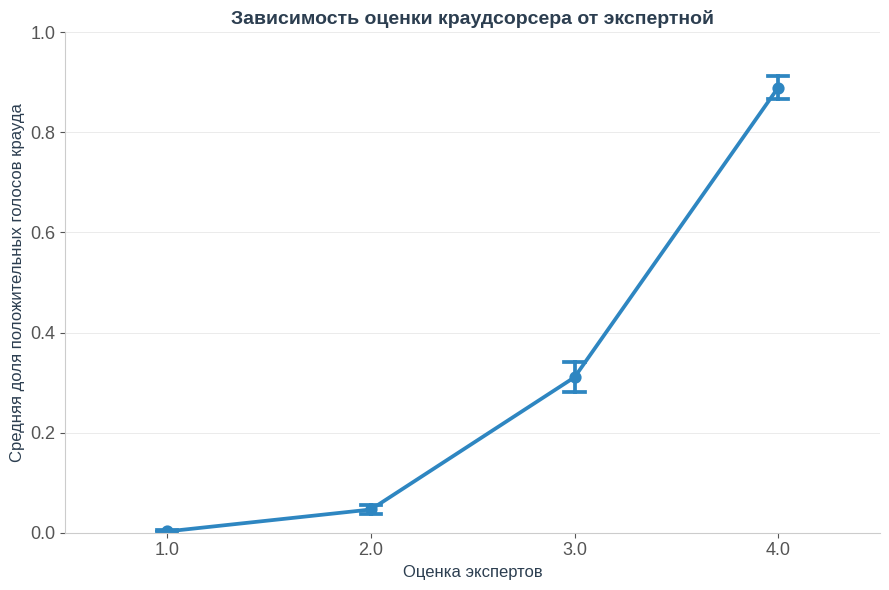

In [39]:
fig, ax = plt.subplots(figsize=(9, 6))

sns.pointplot(
    data=annotation_compare_clean_df,
    x='expert_score',
    y='fraction',
    errorbar=('ci', 95),
    color=BLUE,
    capsize=0.1,
    ax=ax
)

ax.set_title('Зависимость оценки краудсорсера от экспертной')
ax.set_xlabel('Оценка экспертов')
ax.set_ylabel('Средняя доля положительных голосов крауда')
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

График демонстрирует выраженную положительную зависимость между экспертной и краудсорсинговой оценками.  
С увеличением итоговой оценки экспертов средняя доля положительных голосов крауда последовательно возрастает - от значений, близких к нулю, для экспертной оценки 1 до 0.89 для оценки 4. Доверительные интервалы относительно невелики, что подтверждает устойчивость наблюдаемой зависимости. Таким образом, два источника разметки в целом согласованно оценивают релевантность пар "изображение—описание".

Определим корреляцию:

In [40]:
pearson_corr = annotation_compare_clean_df[
    ['expert_score', 'fraction']
].corr(method='pearson').iloc[0, 1]

spearman_corr = annotation_compare_clean_df[
    ['expert_score', 'fraction']
].corr(method='spearman').iloc[0, 1]

print(f'Корреляция Пирсона:  {pearson_corr:.3f}')
print(f'Корреляция Спирмена: {spearman_corr:.3f}')

Корреляция Пирсона:  0.768
Корреляция Спирмена: 0.718


Между экспертной и краудсорсинговой оценками наблюдается сильная положительная связь. Коэффициент корреляции Пирсона составляет 0.768, а коэффициент Спирмена — 0.718.  
Полученные значения подтверждают, что с ростом экспертной оценки увеличивается и доля положительных голосов краудсорсеров.  

Сформируем целевую переменную на основе агрегированной экспертной оценки, а CrowdAnnotations оставляем как дополнительное подтверждение качества экспертной разметки.

Объединим тренировочный датасет с данными по экспертной оценке:

In [41]:
train_model_df = train_df.merge(
    expert_annotations_df[
        ['image', 'query_id', 'expert_score']
    ],
    on=['image', 'query_id'],
    how='left'
)

train_model_df.head()

,image,query_id,query_text,expert_score
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,1.0
1,1262583859_653f1469a9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,1.0
2,2447284966_d6bbdb4b6e.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,2.0
3,2549968784_39bfbe44f9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,4.0
4,2621415349_ef1a7e73be.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,1.0


Сопоставим получившийся результат:

In [42]:
print('Размер train_df:', train_df.shape)
print('Размер после объединения:', train_model_df.shape)

print(
    'Пропусков в expert_score:',
    train_model_df['expert_score'].isna().sum()
)

Размер train_df: (5822, 3)
Размер после объединения: (5822, 4)
Пропусков в expert_score: 126


Объединение произошло успешно. Есть данные с пропущенными значениями. В силу их количества, их можно удалить:

In [43]:
train_model_df = (
    train_model_df
    .dropna(subset=['expert_score'])
    .reset_index(drop=True)
)

print('Размер выборки:', train_model_df.shape)

Размер выборки: (5696, 4)


Переведем экспертную оценку от 0 до 1:

In [44]:
train_model_df['target'] = (
    train_model_df['expert_score'] - 1
) / 3

train_model_df[
    ['expert_score', 'target']
].drop_duplicates().sort_values(
    'expert_score'
).reset_index(drop=True)

,expert_score,target
0,1.0,0.000000
1,2.0,0.333333
2,3.0,0.666667
3,4.0,1.000000


Визуализируем распределение целевой перемонной:

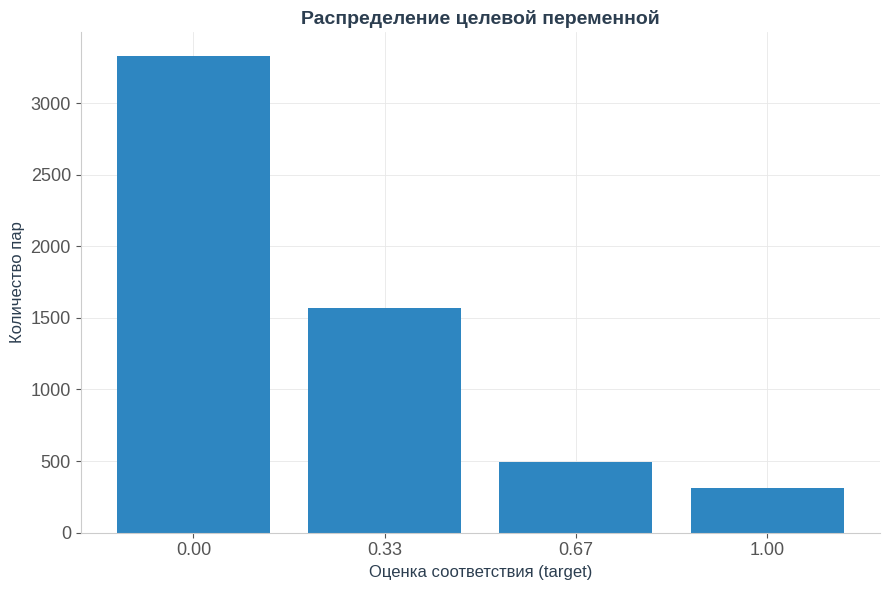

In [45]:
target_counts = (
    train_model_df['target']
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.bar(
    range(len(target_counts)),
    target_counts.values,
    color=BLUE
)

ax.set_xticks(range(len(target_counts)))
ax.set_xticklabels(['0.00', '0.33', '0.67', '1.00'])

ax.set_title('Распределение целевой переменной')
ax.set_xlabel('Оценка соответствия (target)')
ax.set_ylabel('Количество пар')

plt.tight_layout()
plt.show()

В качестве целевой переменной выбрана агрегированная экспертная оценка, поскольку экспертная разметка полностью покрывает исходную обучающую выборку и демонстрирует сильную согласованность с независимой краудсорсинговой разметкой.  
Для агрегации использовано голосование большинства трёх экспертов.  
126 наблюдений, для которых большинство определить невозможно, исключены.  
Экспертная шкала от 1 до 4 преобразована в диапазон от 0 до 1, необходимый для решения задачи регрессии

<span style="background-color: #6495ED; text-align: center; padding: 8px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 20px; color: white;">
        Этап 4. Проверка данных. Фильтрация контента
    </span>
</span>

Для фильтрации создадим словарь с ключами, так или иначе обозначающих детей:

In [46]:
child_terms = [
    'child', 'children',
    'kid', 'kids',
    'boy', 'boys',
    'girl', 'girls',
    'baby', 'babies',
    'toddler', 'toddlers',
    'infant', 'infants',
    'teen', 'teens',
    'teenager', 'teenagers',
    'schoolboy', 'schoolboys',
    'schoolgirl', 'schoolgirls'
]

**Согласно Кембриджскому словарю, тинейджер - человек в возрасте от 13 до 19 лет. Т.е. у нас пограничное состояние: с одной стороны, это слово соответствует нормативу фильтрации лиц до 16 лет. С другой стороны, под фильтрацию могут попасть лица старше 16 но до 19 лет.  
Однако, в связи с юридическими нормами, лучше отфильтровать ошибочно лицо старше 16 лет, чем выдать результат, нарушающий юридические аспекты.**

Зададим выражение для поиска целых слов из списка:

In [47]:
child_pattern = (
    r'\b(?:'
    + '|'.join(map(re.escape, child_terms))
    + r')\b'
)

Поищем строки, содержащие запрещенные выражения:

In [48]:
restricted_rows = train_model_df[
    train_model_df['query_text'].str.contains(
        child_pattern,
        case=False,
        regex=True,
        na=False
    )
]

print(
    'Количество запрещённых связок:',
    len(restricted_rows)
)

print(
    'Связано с уникальными изображениями:',
    restricted_rows['image'].nunique()
)

Количество запрещённых связок: 1523
Связано с уникальными изображениями: 719


Посмотрим, что запрещенного удалось найти:

In [49]:
restricted_rows[
    ['image', 'query_text']
].drop_duplicates().head(30)

,image,query_text
0,1056338697_4f7d7ce270.jpg,A young child is wearing blue goggles and sitt...
1,1262583859_653f1469a9.jpg,A young child is wearing blue goggles and sitt...
2,2447284966_d6bbdb4b6e.jpg,A young child is wearing blue goggles and sitt...
3,2549968784_39bfbe44f9.jpg,A young child is wearing blue goggles and sitt...
4,2621415349_ef1a7e73be.jpg,A young child is wearing blue goggles and sitt...
5,3030566410_393c36a6c5.jpg,A young child is wearing blue goggles and sitt...
6,3155451946_c0862c70cb.jpg,A young child is wearing blue goggles and sitt...
7,3222041930_f642f49d28.jpg,A young child is wearing blue goggles and sitt...
8,343218198_1ca90e0734.jpg,A young child is wearing blue goggles and sitt...
9,3718964174_cb2dc1615e.jpg,A young child is wearing blue goggles and sitt...


Как видим из полученных результатов, определился список запрещенных слов, соответственно кандидатов на удаление.  

Стоит учитывать, что одно и то же изображение может встречаться несколько раз, и лишь в одном случае описание будет содержать запрещенное слово. Важно, что удаление только одного такого случая оставит другие изображения не тронутыми, что будет нарушать юридические нормы. Изображение необходимо удалять полностью.    

Из полученных результатов видно, что у разных изображений встречается одно и то же описание (напр. _"A young boy dressed in a red uniform..."_).  
Необходимо пересмотреть условия фильтрации. Выделим исходное изображение из 'query_id' и проверим детские описания только тогда, когда описание относится к этому же изображению:

In [50]:
train_model_df['query_image'] = (
    train_model_df['query_id']
    .str.split('#')
    .str[0]
)

restricted_source_rows = train_model_df[
    (train_model_df['image'] == train_model_df['query_image'])
    &
    (
        train_model_df['query_text'].str.contains(
            child_pattern,
            case=False,
            regex=True,
            na=False
        )
    )
].copy()

print(
    'Запрещенный контент:',
    len(restricted_source_rows)
)

print(
    'Связано с уникальными изображениями:',
    restricted_source_rows['image'].nunique()
)

Запрещенный контент: 37
Связано с уникальными изображениями: 37


In [51]:
restricted_source_rows[
    ['image', 'query_text']
].drop_duplicates().head(15)

,image,query_text
3,2549968784_39bfbe44f9.jpg,A young child is wearing blue goggles and sitt...
16,2718495608_d8533e3ac5.jpg,A girl wearing a yellow shirt and sunglasses s...
84,2140182410_8e2a06fbda.jpg,The kid is on a float in the snow .
212,191003285_edd8d0cf58.jpg,A man and young girl eat a meal on a city stre...
236,3388330419_85d72f7cda.jpg,Two little girls dance on a hardwood floor in ...
400,3549583146_3e8bb2f7e9.jpg,A young boy is riding a bike .
401,1131932671_c8d17751b3.jpg,A boy jumps from one bed to another .
405,3245460937_2710a82709.jpg,A child jumping on a tennis court .
539,2594042571_2e4666507e.jpg,A smiling boy in an orange shirt with a safari...
713,3470951932_27ed74eb0b.jpg,A boy runs to a baseball base .


Вместо 719 изображений удалось сократить до 37 изображений, для которых именно их собственное описание содержит метку детского контента.

Фильтрация работает корректней и точечней, нежели предыдущий вариант. 37 изображений можно удалить:

In [52]:
restricted_images = restricted_source_rows['image'].unique()

train_model_filtered_df = train_model_df[
    ~train_model_df['image'].isin(restricted_images)
].copy()

train_model_filtered_df.reset_index(
    drop=True,
    inplace=True
)

print('Строк до фильтрации:', len(train_model_df))
print('Строк после фильтрации:', len(train_model_filtered_df))

print(
    'Удалено строк:',
    len(train_model_df) - len(train_model_filtered_df)
)

print(
    'Удалено изображений:',
    len(restricted_images)
)

print(
    'Уникальных изображений после фильтрации:',
    train_model_filtered_df['image'].nunique()
)

remaining_restricted = train_model_filtered_df[
    'image'
].isin(restricted_images).sum()

print(
    'Запрещённых изображений:',
    remaining_restricted
)

Строк до фильтрации: 5696
Строк после фильтрации: 5492
Удалено строк: 204
Удалено изображений: 37
Уникальных изображений после фильтрации: 963
Запрещённых изображений: 0


Временный столбец можно удалить:

In [53]:
train_model_filtered_df.drop(
    columns='query_image',
    inplace=True
)

**Промежуточный вывод:**  
Для выявления потенциально запрещённого контента анализировались текстовые описания, исходно относящиеся к соответствующим изображениям. Такой подход позволил избежать удаления изображений, случайно сопоставленных с описаниями детского контента в отрицательных обучающих парах.
  
В результате было выявлено 37 изображений с признаками присутствия лиц до 16 лет. Поскольку точный возраст человека по текстовому описанию определить невозможно, принято решение исключить данные изображения из обучающей выборки.  
  
После фильтрации размер обучающей выборки сократился с 5 696 до 5 492 пар, а количество уникальных изображений — до 963.  
Запрещенные изображения в итоговой выборке отсутствуют.

<span style="background-color: #6495ED; text-align: center; padding: 8px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 20px; color: white;">
        Этап 5. Подготовка данных
    </span>
</span>

Разделим отфильтрованную тренировочную выборку по группам изображений в соотношении 70/30, чтобы одно и то же изображение не оказалось одновременно в разных выборках. Используем ***'GroupShuffleSplit'***:

In [54]:
gss_train = GroupShuffleSplit(
    n_splits=1,
    train_size=0.70,
    random_state=RANDOM_STATE
)

train_idx, temp_idx = next(
    gss_train.split(
        train_model_filtered_df,
        groups=train_model_filtered_df['image']
    )
)

train_split_df = (
    train_model_filtered_df
    .iloc[train_idx]
    .reset_index(drop=True)
)

temp_split_df = (
    train_model_filtered_df
    .iloc[temp_idx]
    .reset_index(drop=True)
)

Получившиеся 30% выборку разбиваем наполовину:

In [55]:
gss_temp = GroupShuffleSplit(
    n_splits=1,
    train_size=0.50,
    random_state=RANDOM_STATE
)

val_idx, test_idx = next(
    gss_temp.split(
        temp_split_df,
        groups=temp_split_df['image']
    )
)

val_split_df = (
    temp_split_df
    .iloc[val_idx]
    .reset_index(drop=True)
)

test_split_df = (
    temp_split_df
    .iloc[test_idx]
    .reset_index(drop=True)
)

Проведем проверку на наличие пересечений изображение-описание в получившихся выборках:

In [56]:
train_images = set(train_split_df['image'])
val_images = set(val_split_df['image'])
test_images = set(test_split_df['image'])

print(
    'Train - Validation:',
    len(train_images & val_images)
)

print(
    'Train - Test:',
    len(train_images & test_images)
)

print(
    'Validation - Test:',
    len(val_images & test_images)
)

Train - Validation: 0
Train - Test: 0
Validation - Test: 0


Пара "изображение - описание" не пересекаются в выборках.

Проверим получившееся распределение в выборках:

In [57]:
target_distribution = pd.concat([
    train_split_df['target']
        .value_counts(normalize=True)
        .sort_index()
        .rename('Train'),

    val_split_df['target']
        .value_counts(normalize=True)
        .sort_index()
        .rename('Validation'),

    test_split_df['target']
        .value_counts(normalize=True)
        .sort_index()
        .rename('Test')
], axis=1)

target_distribution.round(3)

,Train,Validation,Test
target,,,
0.000000,0.587,0.579,0.598
0.333333,0.279,0.273,0.270
0.666667,0.083,0.105,0.082
1.000000,0.050,0.043,0.050


Структура сохраняется во всех получившихся выборках: больше всего несовпадающих пар, где target - 0, далее 0.33, затем 0.67 и меньше всего полностью релевантных - 1.

**Промежуточный вывод:**  
Очищенная выборка была разделена на обучающую, валидационную и тестовую части с помощью GroupShuffleSplit. В качестве групп использовались изображения, благодаря чему все пары с одним изображением попадают только в одну из выборок, что предотвращает утечку данных при дальнейшем обучении модели

<span style="background-color: #6495ED; text-align: center; padding: 8px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 20px; color: white;">
        Этап 6. Векторизация изображений
    </span>
</span>

Используем ResNet50:

In [58]:
resnet_weights = ResNet50_Weights.DEFAULT

resnet_model = resnet50(
    weights=resnet_weights
)

resnet_model.fc = nn.Identity()

resnet_model = resnet_model.to(DEVICE)
resnet_model.eval()

image_transform = resnet_weights.transforms()

Получим эмбеддинги всех уникальных изображений:

In [59]:
def get_image_embedding(image_name):

    image_path = os.path.join(
        TRAIN_IMAGES_PATH,
        image_name
    )

    image = Image.open(image_path).convert('RGB')

    image_tensor = image_transform(image)
    image_tensor = image_tensor.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        embedding = resnet_model(image_tensor)

    return (
        embedding
        .squeeze(0)
        .cpu()
        .numpy()
    )

In [60]:
# сформируем список:

unique_images = (
    train_model_filtered_df['image']
    .drop_duplicates()
    .tolist()
)


Используем обработку через 'DataLoader' для оптимальной работы на GPU без использования обработки по одному изображению:

In [61]:
# создаем класс:

class ImageEmbeddingDataset(Dataset):

    def __init__(
        self,
        image_names,
        image_dir,
        transform
    ):
        self.image_names = image_names
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):

        image_name = self.image_names[idx]

        image_path = os.path.join(
            self.image_dir,
            image_name
        )

        image = Image.open(
            image_path
        ).convert('RGB')

        image = self.transform(image)

        return image, image_name

In [62]:
# Применим DataLoader:
image_dataset = ImageEmbeddingDataset(
    image_names=unique_images,
    image_dir=TRAIN_IMAGES_PATH,
    transform=image_transform
)

image_loader = DataLoader(
    image_dataset,
    batch_size=64,
    num_workers=2,
    shuffle=False
)

Векторизируем изображения:

In [63]:
image_embeddings = {}

with torch.no_grad():

    for images, image_names in image_loader:

        images = images.to(DEVICE)

        embeddings = resnet_model(images)
        embeddings = embeddings.cpu().numpy()

        for image_name, embedding in zip(
            image_names,
            embeddings
        ):
            image_embeddings[image_name] = embedding

Проверим результат:

In [64]:
print(
    'Получено эмбеддингов:',
    len(image_embeddings)
)

print(
    'Размер одного эмбеддинга:',
    next(iter(image_embeddings.values())).shape
)

Получено эмбеддингов: 963
Размер одного эмбеддинга: (2048,)


**Промежуточный вывод:**
Для извлечения признаков изображений использована предобученная свёрточная нейронная сеть ResNet50.  
Чтобы избежать повторной обработки одних и тех же изображений, векторизация выполнялась только для 963 уникальных изображений. Изображения обрабатывались при помощи Dataset и DataLoader, что позволяет эффективнее использовать вычислительные ресурсы.

<span style="background-color: #6495ED; text-align: center; padding: 8px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 20px; color: white;">
        Этап 7. Векторизация текста
    </span>
</span>

Для векторизации текстовых описаний будем применять BERT

In [65]:
tokenizer = AutoTokenizer.from_pretrained(
    'bert-base-uncased'
)

bert_model = AutoModel.from_pretrained(
    'bert-base-uncased'
)

bert_model = bert_model.to(DEVICE)
bert_model.eval();

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Создадим текстовые запросы%:

In [66]:
unique_queries_df = (
    train_model_filtered_df[
        ['query_id', 'query_text']
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

unique_queries_df.head(10)

,query_id,query_text
0,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...
1,2718495608_d8533e3ac5.jpg#2,A girl wearing a yellow shirt and sunglasses s...
2,3181701312_70a379ab6e.jpg#2,A man sleeps under a blanket on a city street .
3,3207358897_bfa61fa3c6.jpg#2,A woman plays with long red ribbons in an empt...
4,3286822339_5535af6b93.jpg#2,Chinese market street in the winter time .
5,3360930596_1e75164ce6.jpg#2,A soccer ball is above the head of a man weari...
6,3545652636_0746537307.jpg#2,A young boy dressed in a red uniform kicks the...
7,434792818_56375e203f.jpg#2,A man and woman look back at the camera while ...
8,1425069308_488e5fcf9d.jpg#2,A white dog jumps to catch a blue ball in a li...
9,1714316707_8bbaa2a2ba.jpg#2,A little boy shakes the snow off of a tree .


Обозначим один вектор для всего предложения:

In [67]:
def mean_pooling(model_output, attention_mask):

    token_embeddings = (
        model_output.last_hidden_state
    )

    input_mask_expanded = (
        attention_mask
        .unsqueeze(-1)
        .expand(token_embeddings.size())
        .float()
    )

    summed_embeddings = torch.sum(
        token_embeddings * input_mask_expanded,
        dim=1
    )

    summed_mask = torch.clamp(
        input_mask_expanded.sum(dim=1),
        min=1e-9
    )

    return summed_embeddings / summed_mask

Применим пакеты:

In [68]:
text_embeddings = {}

BERT_BATCH_SIZE = 64

with torch.no_grad():

    for start in range(
        0,
        len(unique_queries_df),
        BERT_BATCH_SIZE
    ):

        batch = unique_queries_df.iloc[
            start:start + BERT_BATCH_SIZE
        ]

        texts = batch['query_text'].tolist()

        encoded = tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors='pt'
        )

        encoded = {
            key: value.to(DEVICE)
            for key, value in encoded.items()
        }

        model_output = bert_model(
            **encoded
        )

        embeddings = mean_pooling(
            model_output,
            encoded['attention_mask']
        )

        embeddings = embeddings.cpu().numpy()

        for query_id, embedding in zip(
            batch['query_id'],
            embeddings
        ):
            text_embeddings[query_id] = embedding

In [69]:
print(
    'Получено текстовых эмбеддингов:',
    len(text_embeddings)
)

print(
    'Размер одного эмбеддинга:',
    next(iter(text_embeddings.values())).shape
)

Получено текстовых эмбеддингов: 974
Размер одного эмбеддинга: (768,)


**Промежуточный вывод:**  
Для векторизации текстовых описаний использована предобученная модель BERT: каждый уникальный текстовый запрос обработан один раз, после чего с помощью усреднения представлений токенов сформирован единый вектор признаков.  
  
В результате получено 974 текстовых эмбеддинга размерностью 768 признаков каждый. Полученные текстовые векторы далее будут объединены с 2048-мерными векторами изображений

<span style="background-color: #6495ED; text-align: center; padding: 8px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 20px; color: white;">
        Этап 8. Объединение векторов
    </span>
</span>

Объединим признаки изображений и текста в одну матрицу:

In [70]:
def build_feature_matrix(df):

    features = []

    for row in df.itertuples(index=False):

        image_vector = image_embeddings[
            row.image
        ]

        text_vector = text_embeddings[
            row.query_id
        ]

        combined_vector = np.concatenate([
            image_vector,
            text_vector
        ])

        features.append(combined_vector)

    return np.vstack(features)

X_train = build_feature_matrix(
    train_split_df
)

X_val = build_feature_matrix(
    val_split_df
)

X_test = build_feature_matrix(
    test_split_df
)

y_train = train_split_df[
    'target'
].to_numpy()

y_val = val_split_df[
    'target'
].to_numpy()

y_test = test_split_df[
    'target'
].to_numpy()

Проверим получившиеся размерности:

In [71]:
print('X_train:', X_train.shape)
print('y_train:', y_train.shape)

print('X_val:', X_val.shape)
print('y_val:', y_val.shape)

print('X_test:', X_test.shape)
print('y_test:', y_test.shape)

X_train: (3823, 2816)
y_train: (3823,)
X_val: (828, 2816)
y_val: (828,)
X_test: (841, 2816)
y_test: (841,)


**Промежуточный вывод:**  
Векторы изображений и текстовых описаний были объединены в единое признаковое пространство. Для каждой пары "изображение—описание" сформирован вектор размерностью 2816 признаков - 2048 признаков изображения и 768 текстовых признаков

<span style="background-color: #6495ED; text-align: center; padding: 8px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 20px; color: white;">
        Этап 9. Обучение модели
    </span>
</span>

<div style="background-color: #F5F5DC; text-align: center; padding: 12px; border-radius: 10px;">
    <span style="font-weight: bold; font-size: 20px; color: #333;">
        LinearRegression
    </span>
</div>

За основную модель возьмем LinearRegression:

In [72]:
%%time

linear_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

linear_pipeline.fit(
    X_train,
    y_train
)

CPU times: user 15.9 s, sys: 123 ms, total: 16 s
Wall time: 17.2 s


Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])

Осуществим прогнозирование:

In [73]:
y_val_pred_linear = linear_pipeline.predict(
    X_val
)

Вычислим метрики:

In [74]:
val_rmse_linear = np.sqrt(
    mean_squared_error(
        y_val,
        y_val_pred_linear
    )
)

val_mae_linear = mean_absolute_error(
    y_val,
    y_val_pred_linear
)

<div style="background-color: #F5F5DC; text-align: center; padding: 12px; border-radius: 10px;">
    <span style="font-weight: bold; font-size: 20px; color: #333;">
        LightGBM
    </span>
</div>

Обучаем модель:

In [75]:
%%time

lgbm_pipeline = Pipeline([
    (
        'model',
        LGBMRegressor(
            n_estimators=500,
            learning_rate=0.03,
            num_leaves=31,
            max_depth=-1,
            random_state=RANDOM_STATE
        )
    )
])

lgbm_pipeline.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.346557 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 680593
[LightGBM] [Info] Number of data points in the train set: 3823, number of used features: 2816
[LightGBM] [Info] Start training from score 0.198884
CPU times: user 2min 59s, sys: 436 ms, total: 3min
Wall time: 3min 3s


Pipeline(steps=[('model',
                 LGBMRegressor(learning_rate=0.03, n_estimators=500,
                               random_state=2026))])

Узнаем результаты, метрики:

In [76]:
y_val_pred_lgbm = lgbm_pipeline.predict(
    X_val
)

val_rmse_lgbm = np.sqrt(
    mean_squared_error(
        y_val,
        y_val_pred_lgbm
    )
)

val_mae_lgbm = mean_absolute_error(
    y_val,
    y_val_pred_lgbm
)

<div style="background-color: #F5F5DC; text-align: center; padding: 12px; border-radius: 10px;">
    <span style="font-weight: bold; font-size: 20px; color: #333;">
        Нейронная сеть
    </span>
</div>

Применим масштабирование:

In [77]:
nn_scaler = StandardScaler()

X_train_scaled_nn = nn_scaler.fit_transform(
    X_train
)

X_val_scaled_nn = nn_scaler.transform(
    X_val
)

Создадим тензоры:

In [78]:
X_train_tensor = torch.tensor(
    X_train_scaled_nn,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.float32
).unsqueeze(1)

X_val_tensor = torch.tensor(
    X_val_scaled_nn,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.float32
).unsqueeze(1)

train_dataset_nn = torch.utils.data.TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset_nn = torch.utils.data.TensorDataset(
    X_val_tensor,
    y_val_tensor
)

train_loader_nn = DataLoader(
    train_dataset_nn,
    batch_size=64,
    shuffle=True
)

val_loader_nn = DataLoader(
    val_dataset_nn,
    batch_size=64,
    shuffle=False
)

Создадим архитектуру:

In [79]:
class RelevanceNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(2816, 512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

In [80]:
nn_model = RelevanceNet().to(DEVICE)

In [81]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    nn_model.parameters(),
    lr=0.001
)

EPOCHS = 100
PATIENCE = 10

best_val_rmse = float('inf')
best_model_state = None
epochs_without_improvement = 0

history = {
    'train_rmse': [],
    'val_rmse': []
}

Обучаем модель с применением Early Stopping:

In [82]:
%%time

for epoch in range(1, EPOCHS + 1):

    nn_model.train()

    train_squared_errors = []

    for X_batch, y_batch in train_loader_nn:

        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()

        predictions = nn_model(
            X_batch
        )

        loss = criterion(
            predictions,
            y_batch
        )

        loss.backward()
        optimizer.step()

        squared_errors = (
            predictions.detach() - y_batch
        ) ** 2

        train_squared_errors.append(
            squared_errors.cpu().numpy()
        )

    train_squared_errors = np.concatenate(
        train_squared_errors
    )

    train_rmse = np.sqrt(
        train_squared_errors.mean()
    )

    nn_model.eval()

    val_squared_errors = []

    with torch.no_grad():

        for X_batch, y_batch in val_loader_nn:

            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            predictions = nn_model(
                X_batch
            )

            squared_errors = (
                predictions - y_batch
            ) ** 2

            val_squared_errors.append(
                squared_errors.cpu().numpy()
            )

    val_squared_errors = np.concatenate(
        val_squared_errors
    )

    val_rmse = np.sqrt(
        val_squared_errors.mean()
    )

    history['train_rmse'].append(
        train_rmse
    )

    history['val_rmse'].append(
        val_rmse
    )

    if val_rmse < best_val_rmse:

        best_val_rmse = val_rmse

        best_model_state = {
            key: value.cpu().clone()
            for key, value
            in nn_model.state_dict().items()
        }

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:

        print(
            f'Early stopping на эпохе {epoch}'
        )

        break

Early stopping на эпохе 23
CPU times: user 5.01 s, sys: 117 ms, total: 5.13 s
Wall time: 5.25 s


Загрузим лучшую нейросеть:

In [83]:
nn_model.load_state_dict(
    best_model_state
)

nn_model = nn_model.to(DEVICE)

Прогноз от лучшей нейросети:

In [84]:
nn_model.eval()

with torch.no_grad():

    y_val_pred_nn = (
        nn_model(
            X_val_tensor.to(DEVICE)
        )
        .cpu()
        .numpy()
        .ravel()
    )

Посчитаем метрики:

In [85]:
val_rmse_nn = np.sqrt(
    mean_squared_error(
        y_val,
        y_val_pred_nn
    )
)

val_mae_nn = mean_absolute_error(
    y_val,
    y_val_pred_nn
)

**Создадим агрегированную таблицу с результатами трех моделей:**

In [86]:
results = pd.DataFrame({
    'Модель': [
        'LinearRegression',
        'LightGBM',
        'Neural Network'
    ],
    'RMSE': [
        val_rmse_linear,
        val_rmse_lgbm,
        val_rmse_nn
    ],
    'MAE': [
        val_mae_linear,
        val_mae_lgbm,
        val_mae_nn
    ]
})

results.sort_values(
    'RMSE'
).round(4)

,Модель,RMSE,MAE
2,Neural Network,0.2147,0.1509
1,LightGBM,0.2391,0.1876
0,LinearRegression,0.3450,0.2699


**Промежуточный вывод:**  
Были обучены и сравнены три модели: LinearRegression, LightGBM и нейронная сеть.

В качестве основной метрики использовалась RMSE, которая показывает среднюю величину ошибки прогноза с повышенным штрафом за большие отклонения. Дополнительно была рассчитана метрика MAE, отражающая среднюю абсолютную ошибку предсказаний.

Наибольшее значение RMSE на валидационной выборке показала модель LinearRegression — 0.3450. Модель LightGBM продемонстрировала более высокий результат качества: значение RMSE составило 0.2391. Наилучший результат показала нейронная сеть — RMSE 0.2147.

Значения дополнительной метрики MAE подтверждают полученный результат: для LinearRegression она составила 0.2699, для LightGBM 0.1876, а для нейронной сети 0.1509.

Таким образом, нейронная сеть показала наилучшее качество по обеим рассматриваемым метрикам. Поскольку именно эта модель продемонстрировала минимальные значения RMSE и MAE на валидационной выборке, она была выбрана для дальнейшей оценки на тестовой выборке.

<span style="background-color: #6495ED; text-align: center; padding: 8px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 20px; color: white;">
        Этап 10. Тестирование лучшей модели
    </span>
</span>

**Протестируем лучшую модель:**

In [87]:
X_test_scaled_nn = nn_scaler.transform(
    X_test
)

X_test_tensor = torch.tensor(
    X_test_scaled_nn,
    dtype=torch.float32
).to(DEVICE)

nn_model.eval()

with torch.no_grad():
    y_test_pred_nn = nn_model(
        X_test_tensor
    ).cpu().numpy().ravel()

rmse_test_nn = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_nn
    )
)

mae_test_nn = mean_absolute_error(
    y_test,
    y_test_pred_nn
)

rmse_val_nn = val_rmse_nn
mae_val_nn = val_mae_nn
print('RMSE:')
print(f'RMSE Validation: {rmse_val_nn:.4f}')
print(f'RMSE Test:       {rmse_test_nn:.4f}')
print(f'Разница RMSE:    {rmse_test_nn - rmse_val_nn:.4f}')

print()

print('MAE:')
print(f'MAE Validation:  {mae_val_nn:.4f}')
print(f'MAE Test:        {mae_test_nn:.4f}')
print(f'Разница MAE:     {mae_test_nn - mae_val_nn:.4f}')

RMSE:
RMSE Validation: 0.2147
RMSE Test:       0.2239
Разница RMSE:    0.0093

MAE:
MAE Validation:  0.1509
MAE Test:        0.1556
Разница MAE:     0.0047


**Промежуточный вывод:**
Наилучшая модель (нейросеть) была проверена на тестовой выборке.

Значение RMSE на валидационной выборке составило 0.2147, а на тестовой 0.2239. Разница между значениями метрики составила 0.0093, что указывает на небольшое снижение качества на ранее не использовавшихся данных.

Аналогичная картина наблюдается для MAE: на валидационной выборке значение метрики составило 0.1509, а на тестовой 0.1556. Разница составила 0.0047.

Значения RMSE и MAE на тестовой выборке лишь незначительно превышают результаты на валидационной выборке, что свидетельствует о том, что модель сохраняет стабильное качество на новых данных.

<div style="background-color: #F5F5DC; text-align: center; padding: 12px; border-radius: 10px;">
    <span style="font-weight: bold; font-size: 20px; color: #333;">
        Тестирование поиска изображений
    </span>
</div>

Получим эмбеддинги тестовых изображений:

In [88]:
test_image_names = (
    test_images_df['image']
    .drop_duplicates()
    .tolist()
)

test_image_dataset = ImageEmbeddingDataset(
    image_names=test_image_names,
    image_dir=TEST_IMAGES_PATH,
    transform=image_transform
)

test_image_loader = DataLoader(
    test_image_dataset,
    batch_size=64,
    shuffle=False
)

test_image_embeddings = {}

resnet_model.eval()

with torch.no_grad():

    for images, image_names in test_image_loader:

        images = images.to(DEVICE)

        embeddings = resnet_model(
            images
        )

        embeddings = (
            embeddings
            .cpu()
            .numpy()
        )

        for image_name, embedding in zip(
            image_names,
            embeddings
        ):

            test_image_embeddings[
                image_name
            ] = embedding

Проверим результат:

In [89]:
print(
    'Количество тестовых изображений:',
    len(test_image_embeddings)
)

print(
    'Размерность эмбеддинга:',
    next(
        iter(test_image_embeddings.values())
    ).shape
)

Количество тестовых изображений: 100
Размерность эмбеддинга: (2048,)


Определим тестовые изображения, относящиеся к запрещенному контенту:

In [90]:
test_queries_df['query_image'] = (
    test_queries_df['query_id']
    .str.split('#')
    .str[0]
)

Находим изображения, у которых имеется хотя бы одно из запрещенного в описании:

In [91]:
restricted_test_images = (
    test_queries_df.loc[
        test_queries_df['query_text'].str.contains(
            child_pattern,
            case=False,
            regex=True,
            na=False
        ),
        'query_image'
    ]
    .unique()
)

restricted_test_images = set(
    restricted_test_images
)

print(
    'Количество запрещённых тестовых изображений:',
    len(restricted_test_images)
)

Количество запрещённых тестовых изображений: 44


Проверка запрещенного текста:

In [92]:
def is_restricted_query(text):

    return bool(
        re.search(
            child_pattern,
            text,
            flags=re.IGNORECASE
        )
    )

Эмбеддинг запроса:

In [93]:
def get_text_embedding(text):

    encoded = tokenizer(
        [text],
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors='pt'
    )

    encoded = {
        key: value.to(DEVICE)
        for key, value in encoded.items()
    }

    bert_model.eval()

    with torch.no_grad():

        model_output = bert_model(
            **encoded
        )

        embedding = mean_pooling(
            model_output,
            encoded['attention_mask']
        )

    return (
        embedding
        .cpu()
        .numpy()
        .ravel()
    )

Функция для проверки запроса на нежелательный контент:

In [94]:
def is_restricted_query(text):

    return bool(
        re.search(
            child_pattern,
            text,
            flags=re.IGNORECASE
        )
    )

Поиск наиболее соответствующего изображения:

In [95]:
def find_best_image(query_text):

    if is_restricted_query(query_text):

        return None, None

    text_embedding = get_text_embedding(
        query_text
    )

    image_names = [
        image_name
        for image_name in test_image_embeddings
        if image_name not in restricted_test_images
    ]

    features = []

    for image_name in image_names:

        image_embedding = (
            test_image_embeddings[
                image_name
            ]
        )

        combined_embedding = np.concatenate([
            image_embedding,
            text_embedding
        ])

        features.append(
            combined_embedding
        )

    features = np.vstack(
        features
    )

    features_scaled = nn_scaler.transform(
        features
    )

    features_tensor = torch.tensor(
        features_scaled,
        dtype=torch.float32
    ).to(DEVICE)

    nn_model.eval()

    with torch.no_grad():

        scores = (
            nn_model(
                features_tensor
            )
            .cpu()
            .numpy()
            .ravel()
        )

    best_index = np.argmax(
        scores
    )

    best_image = image_names[
        best_index
    ]

    best_score = scores[
        best_index
    ]

    return best_image, best_score

Выполняем условие о 10 случайных запросах:

In [96]:
random_test_queries = (
    test_queries_df
    .sample(
        n=10,
        random_state=RANDOM_STATE
    )
    .reset_index(drop=True)
)

random_test_queries[
    [
        'query_id',
        'query_text'
    ]
]

,query_id,query_text
0,2887171449_f54a2b9f39.jpg#3,Woman in colorful shirt works at sewing machine .
1,2517284816_9b8fd3c6b6.jpg#3,Boys and girls at a party .
2,269650644_059a84ece5.jpg#1,"An ice skating park in winter , with many peop..."
3,2308256827_3c0a7d514d.jpg#4,The little boy is smiling as he crosses a rope...
4,404850242_3a55a4c874.jpg#1,An Asian woman is taking a photograph outside ...
5,973827791_467d83986e.jpg#2,A woman is throwing a bucket of water over a b...
6,3044359043_627488ddf0.jpg#1,A dog is jumping into a pool for a swim compet...
7,3517023411_a8fbd15230.jpg#0,A biker is racing to keep up with the runners
8,2461990494_c5ece064cc.jpg#4,the man is wearing a backpack and sunglasses w...
9,440190907_bf8b7ba8ef.jpg#4,The shoppers are walking in a store .


Поиск контента:

In [97]:
search_results = []

for row in random_test_queries.itertuples(
    index=False
):

    best_image, best_score = find_best_image(
        row.query_text
    )

    search_results.append({
        'query_id': row.query_id,
        'query_text': row.query_text,
        'best_image': best_image,
        'score': best_score
    })

search_results_df = pd.DataFrame(
    search_results
)

search_results_df

,query_id,query_text,best_image,score
0,2887171449_f54a2b9f39.jpg#3,Woman in colorful shirt works at sewing machine .,3520936130_9e90872560.jpg,0.248799
1,2517284816_9b8fd3c6b6.jpg#3,Boys and girls at a party .,None,NaN
2,269650644_059a84ece5.jpg#1,"An ice skating park in winter , with many peop...",3036971334_78187a9570.jpg,0.431273
3,2308256827_3c0a7d514d.jpg#4,The little boy is smiling as he crosses a rope...,None,NaN
4,404850242_3a55a4c874.jpg#1,An Asian woman is taking a photograph outside ...,404850242_3a55a4c874.jpg,0.405592
5,973827791_467d83986e.jpg#2,A woman is throwing a bucket of water over a b...,None,NaN
6,3044359043_627488ddf0.jpg#1,A dog is jumping into a pool for a swim compet...,3044359043_627488ddf0.jpg,0.521591
7,3517023411_a8fbd15230.jpg#0,A biker is racing to keep up with the runners,3356748019_2251399314.jpg,0.503630
8,2461990494_c5ece064cc.jpg#4,the man is wearing a backpack and sunglasses w...,3520936130_9e90872560.jpg,0.465684
9,440190907_bf8b7ba8ef.jpg#4,The shoppers are walking in a store .,3520936130_9e90872560.jpg,0.487037


Выведем результаты на экран:

Запрос: Woman in colorful shirt works at sewing machine .


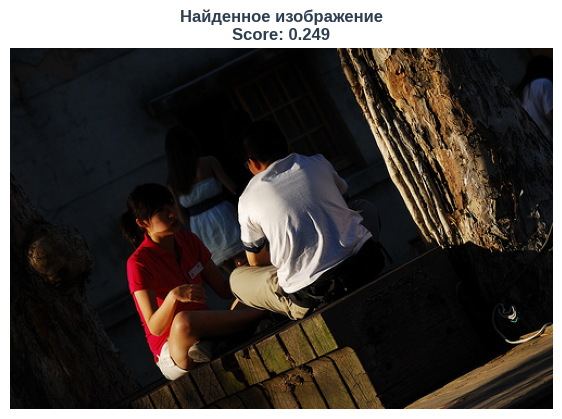

Файл: 3520936130_9e90872560.jpg
--------------------------------------------------------------------------------
Запрос: Boys and girls at a party .
This image is unavailable in your country in compliance with local laws.
--------------------------------------------------------------------------------
Запрос: An ice skating park in winter , with many people .


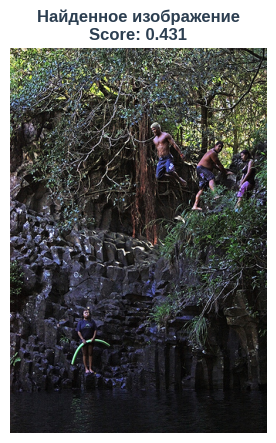

Файл: 3036971334_78187a9570.jpg
--------------------------------------------------------------------------------
Запрос: The little boy is smiling as he crosses a rope on an assault course .
This image is unavailable in your country in compliance with local laws.
--------------------------------------------------------------------------------
Запрос: An Asian woman is taking a photograph outside a white columned building .


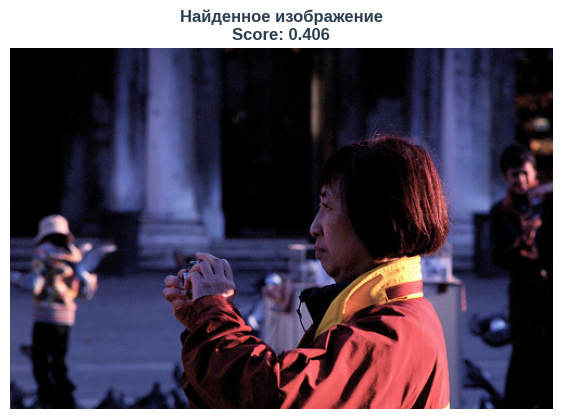

Файл: 404850242_3a55a4c874.jpg
--------------------------------------------------------------------------------
Запрос: A woman is throwing a bucket of water over a baby in the paddling pool .
This image is unavailable in your country in compliance with local laws.
--------------------------------------------------------------------------------
Запрос: A dog is jumping into a pool for a swim competition


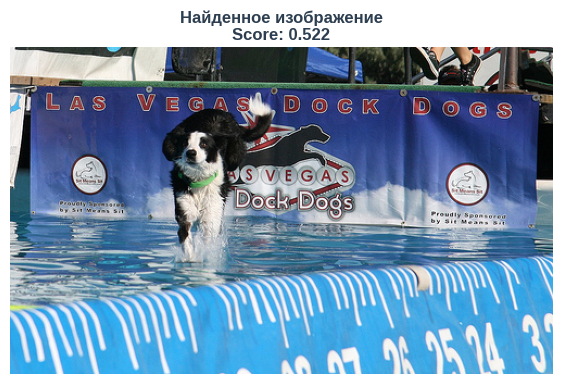

Файл: 3044359043_627488ddf0.jpg
--------------------------------------------------------------------------------
Запрос: A biker is racing to keep up with the runners


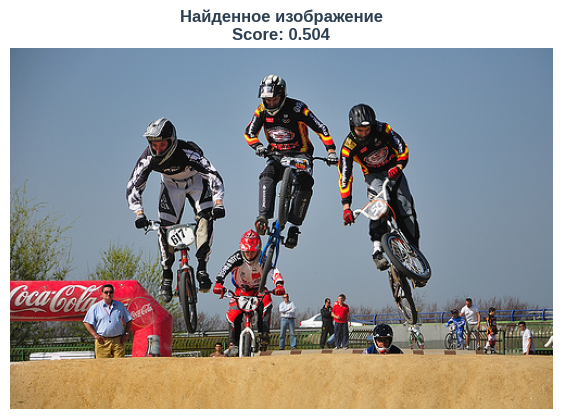

Файл: 3356748019_2251399314.jpg
--------------------------------------------------------------------------------
Запрос: the man is wearing a backpack and sunglasses while walking through an outdoor market .


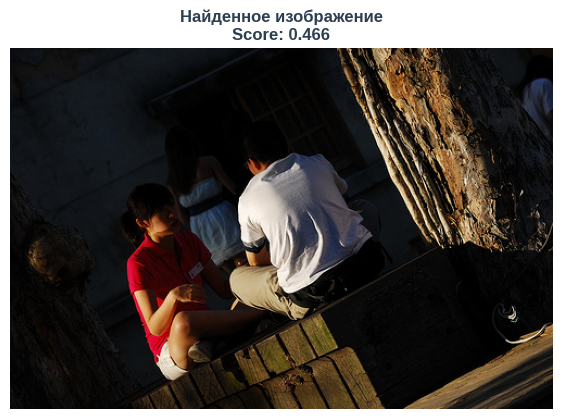

Файл: 3520936130_9e90872560.jpg
--------------------------------------------------------------------------------
Запрос: The shoppers are walking in a store .


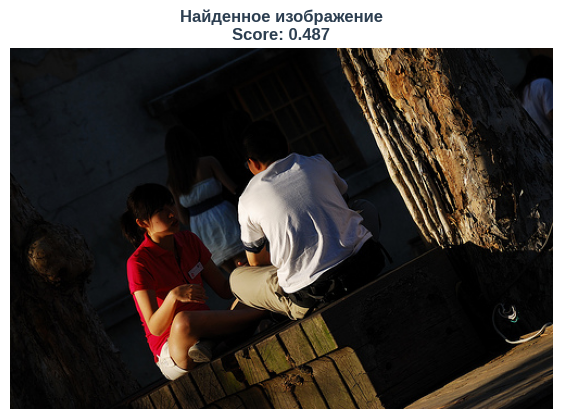

Файл: 3520936130_9e90872560.jpg
--------------------------------------------------------------------------------


In [98]:
for row in search_results_df.itertuples(
    index=False
):

    print(
        f'Запрос: {row.query_text}'
    )

    if row.best_image is None:

        print(
            'This image is unavailable in your '
            'country in compliance with local laws.'
        )

        print('-' * 80)

        continue

    image_path = os.path.join(
        TEST_IMAGES_PATH,
        row.best_image
    )

    image = Image.open(
        image_path
    ).convert('RGB')

    plt.figure(
        figsize=(7, 5)
    )

    plt.imshow(
        image
    )

    plt.axis('off')

    plt.title(
        f'Найденное изображение\n'
        f'Score: {row.score:.3f}',
        fontsize=12
    )

    plt.show()

    print(
        f'Файл: {row.best_image}'
    )

    print('-' * 80)

**Промежуточный вывод:**
На финальном этапе работа поисковой системы была проверена на 10 случайно выбранных текстовых запросах из тестового набора. Для каждого разрешённого запроса модель оценивала соответствие доступных тестовых изображений и возвращала изображение с максимальным предсказанным значением соответствия.

Дополнительно была реализована фильтрация контента в соответствии с требованиями проекта. Запросы, содержащие признаки запрещённой тематики, не обрабатываются поисковой системой, а пользователю выводится соответствующее уведомление. Из набора изображений-кандидатов также исключаются изображения, отнесённые к запрещённому контенту.

Визуальная проверка показала, что для части запросов модель находит изображения, соответствующие их смыслу. Вместе с тем наблюдаются и неточные результаты. Так, некоторые изображения получают максимальную оценку сразу для нескольких различных запросов, а при низких значениях score найденное изображение может слабо соответствовать текстовому описанию.

Таким образом, разработанная система в целом способна выполнять поиск изображений по текстовому описанию и учитывать заданные ограничения на контент, однако качество поиска остаётся неоднородным и может быть улучшено дальнейшим совершенствованием модели и способов представления текста и изображений.

<span style="background-color: #6495ED; text-align: center; padding: 8px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 20px; color: white;">
        Этап 11. Выводы и рекомендации
    </span>
</span>

В ходе проекта была разработана модель машинного обучения для поиска изображений по текстовому описанию для фотохостинга **"Со Смыслом"**.

На этапе подготовки данных были изучены обучающая и тестовая выборки, а также результаты экспертной и краудсорсинговой оценки соответствия текстовых описаний изображениям. Пропущенные значения и полные дубликаты в исходных данных отсутствовали.

В ходе исследовательского анализа была изучена согласованность экспертных оценок. В 58,25% случаев все три эксперта выставили одинаковую оценку, ещё в 39,59% случаев совпали оценки двух из трёх экспертов. Только для 2,16% объектов мнения всех трёх экспертов различались. Для формирования целевого признака была использована оценка большинства экспертов, а наблюдения без согласованной оценки были исключены.

Дополнительно было проведено сравнение экспертных и краудсорсинговых оценок. Между ними была выявлена достаточно сильная положительная связь: коэффициент корреляции Пирсона составил 0,768, Спирмена — 0,718. В качестве целевого признака были выбраны экспертные оценки, поскольку они охватывают значительно большую часть обучающей выборки. Исходная шкала экспертных оценок от 1 до 4 была преобразована в диапазон от 0 до 1.  
  
В соответствии с требованиями проекта из обучающей выборки были исключены изображения с запрещённым контентом. В результате было удалено 37 изображений и 204 связанные с ними пары "изображение-текст". После фильтрации в выборке осталось 5 492 наблюдения и 963 уникальных изображения.

Для предотвращения утечки данных разделение на обучающую, валидационную и тестовую выборки выполнялось по изображениям с помощью GroupShuffleSplit. Это позволило исключить ситуацию, при которой одно и то же изображение одновременно присутствует в разных выборках.

В ходе моделирования были рассмотрены три различных алгоритма: LinearRegression, LightGBM и полносвязная нейронная сеть. Для сравнения моделей использовались метрики RMSE и MAE.

На заключительном этапе была проверена работа модели непосредственно в качестве поисковой системы на 10 случайных текстовых запросах. Для каждого разрешённого запроса модель оценивала соответствие доступных тестовых изображений и возвращала изображение с максимальным прогнозируемым значением релевантности. В соответствии с требованиями проекта была также реализована фильтрация запрещённого контента как на уровне текстовых запросов, так и среди изображений, участвующих в поисковой выдаче.  
  
Визуальный анализ результатов показал, что модель способна находить изображения, соответствующие смыслу текстовых запросов, однако качество поиска остаётся неоднородным. Для части запросов наблюдалось слабое соответствие найденного изображения исходному описанию. Кроме того, некоторые изображения получали максимальную оценку для нескольких различных запросов, что указывает на ограничения построенной модели при определении семантического соответствия текста и изображения.

**Рекомендации по улучшению модели:**
Для дальнейшего повышения качества поиска изображений возможно:

* провести более детальный подбор архитектуры и гиперпараметров нейронной сети;
* увеличить объём обучающей выборки и количество качественных экспертных оценок;